# KNN Monthly Windows with CLR Features

This notebook evaluates rolling monthly windows using CLR-transformed transaction-type percentages and KNN similarity to forecast monthly average `proc_cost`.


# [Note: CLR transform not useful. File has been closed]

## 1. Load Transaction Split Files

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 60)
np.random.seed(404)

data_dir = Path("..") / "Dataset Creation" / "5411_temporal_splits"
train_path = data_dir / "5411_train_with_costs.csv"
validate_path = data_dir / "5411_validate_with_costs.csv"
test_path = data_dir / "5411_test_with_costs.csv"

cost_type_path = Path("..") / "Dataset Creation" / "cost_type_id_18feb.csv"
cost_type_ref = pd.read_csv(cost_type_path)
cost_type_ids = (
    cost_type_ref['cost_type_ID']
    .dropna()
    .astype(int)
    .astype(str)
    .tolist()
)

print(f"Loading from: {data_dir.resolve()}")
print(f"Cost type reference: {cost_type_path.resolve()}")
print(f"Cost types: {len(cost_type_ids)}")

train_df = pd.read_csv(train_path)
validate_df = pd.read_csv(validate_path)
test_df = pd.read_csv(test_path)

all_df = pd.concat([train_df, validate_df, test_df], ignore_index=True)

print(f"Train: {train_df.shape}")
print(f"Validate: {validate_df.shape}")
print(f"Test: {test_df.shape}")
print(f"All: {all_df.shape}")

Loading from: /Users/yattmeo/Desktop/SMU/Code/404_found_us/ml_pipeline/Matt_EDA/Clustering/Dataset Creation/5411_temporal_splits
Cost type reference: /Users/yattmeo/Desktop/SMU/Code/404_found_us/ml_pipeline/Matt_EDA/Clustering/Dataset Creation/cost_type_id_18feb.csv
Cost types: 61
Train: (167323, 12)
Validate: (166883, 12)
Test: (138806, 12)
All: (473012, 12)


## 2. Build Monthly Feature Table

In [7]:
def build_monthly_features(df, cost_type_ids):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])

    df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
    df['proc_cost'] = pd.to_numeric(df['proc_cost'], errors='coerce')

    df['year'] = df['date'].dt.year
    df['month_num'] = df['date'].dt.month
    df['ym'] = df['date'].dt.to_period('M').astype(str)

    # Normalize cost_type_ID for stable pivot columns
    df['cost_type_ID'] = df['cost_type_ID'].fillna(-1).astype(int).astype(str)

    counts = (
        df.groupby(['merchant_id', 'year', 'month_num', 'ym', 'cost_type_ID'])
        .size()
        .rename('count')
        .reset_index()
    )

    cost_counts = counts.pivot_table(
        index=['merchant_id', 'year', 'month_num', 'ym'],
        columns='cost_type_ID',
        values='count',
        fill_value=0
    )

    # Ensure all cost types are present (expected 62)
    cost_counts = cost_counts.reindex(columns=cost_type_ids, fill_value=0)

    total_transactions = cost_counts.sum(axis=1).rename('total_transactions')
    cost_pct = cost_counts.div(total_transactions, axis=0).fillna(0)
    cost_pct.columns = [f"pct_ct_{c}" for c in cost_pct.columns]

    avg_amount = (
        df.groupby(['merchant_id', 'year', 'month_num', 'ym'])['amount']
        .mean()
        .rename('avg_amount')
    )

    target_proc_cost = (
        df.groupby(['merchant_id', 'year', 'month_num', 'ym'])['proc_cost']
        .mean()
        .rename('target_proc_cost')
    )

    features = pd.concat([cost_pct, total_transactions, avg_amount, target_proc_cost], axis=1).reset_index()
    features['ym_period'] = pd.PeriodIndex(features['ym'], freq='M')
    features = features.sort_values(['merchant_id', 'year', 'ym_period'])
    features['month_index'] = features.groupby(['merchant_id', 'year']).cumcount() + 1

    return features

all_monthly = build_monthly_features(all_df, cost_type_ids)
all_monthly = all_monthly[all_monthly['year'].between(2017, 2019)].copy()

print(f"All monthly rows (2017-2019): {all_monthly.shape}")
print(all_monthly.head(3))

All monthly rows (2017-2019): (39931, 70)
   merchant_id  year  month_num       ym  pct_ct_1  pct_ct_2  pct_ct_3  \
0           34  2017          9  2017-09       0.0       1.0       0.0   
1           37  2019          7  2019-07       0.0       0.0       0.0   
2           54  2019          8  2019-08       0.0       0.0       0.0   

   pct_ct_4  pct_ct_5  pct_ct_6  pct_ct_7  pct_ct_8  pct_ct_9  pct_ct_10  \
0       0.0       0.0       0.0       0.0       0.0       0.0        0.0   
1       0.0       0.0       0.0       0.0       0.0       0.0        0.0   
2       0.0       0.0       0.0       0.0       0.0       0.0        0.0   

   pct_ct_11  pct_ct_12  pct_ct_13  pct_ct_14  pct_ct_15  pct_ct_16  \
0        0.0        0.0        0.0        0.0        0.0        0.0   
1        0.0        0.0        0.0        0.0        0.0        0.0   
2        0.0        0.0        0.0        0.0        0.0        0.0   

   pct_ct_17  pct_ct_18  pct_ct_19  pct_ct_20  pct_ct_21  pct_ct_22  \


## 3. Assemble Rolling Context and Target Windows

In [18]:
CLR_EPS = 1e-10
CONTEXT_LEN = 1
HORIZON_LEN = 3
MAPE_EPS = 1e-6

def clr_transform(matrix, eps=CLR_EPS):
    log_x = np.log(matrix + eps)
    return log_x - log_x.mean(axis=1, keepdims=True)

pct_cols = [c for c in all_monthly.columns if c.startswith('pct_ct_')]
base_cols = ['total_transactions', 'avg_amount']

pct_matrix = all_monthly[pct_cols].values
pct_clr = clr_transform(pct_matrix)
pct_clr_cols = [f"clr_{c}" for c in pct_cols]

scaler = StandardScaler()
scaled_base = scaler.fit_transform(all_monthly[base_cols].values)
scaled_base_cols = [f"z_{c}" for c in base_cols]

features_df = pd.DataFrame(pct_clr, columns=pct_clr_cols, index=all_monthly.index)
features_df[scaled_base_cols] = scaled_base
features_df['merchant_id'] = all_monthly['merchant_id'].values
features_df['ym_period'] = all_monthly['ym_period'].values
features_df['year'] = all_monthly['year'].values
features_df['month_num'] = all_monthly['month_num'].values
features_df['target_proc_cost'] = all_monthly['target_proc_cost'].values

feature_cols = pct_clr_cols + scaled_base_cols
print(f"Feature columns: {len(feature_cols)}")
print(features_df.head(3))

Feature columns: 63
   clr_pct_ct_1  clr_pct_ct_2  clr_pct_ct_3  clr_pct_ct_4  clr_pct_ct_5  \
0     -0.377473     22.648378     -0.377473     -0.377473     -0.377473   
1     -0.377473     -0.377473     -0.377473     -0.377473     -0.377473   
2     -0.377473     -0.377473     -0.377473     -0.377473     -0.377473   

   clr_pct_ct_6  clr_pct_ct_7  clr_pct_ct_8  clr_pct_ct_9  clr_pct_ct_10  \
0     -0.377473     -0.377473     -0.377473     -0.377473      -0.377473   
1     -0.377473     -0.377473     -0.377473     -0.377473      -0.377473   
2     -0.377473     -0.377473     -0.377473     -0.377473      -0.377473   

   clr_pct_ct_11  clr_pct_ct_12  clr_pct_ct_13  clr_pct_ct_14  clr_pct_ct_15  \
0      -0.377473      -0.377473      -0.377473      -0.377473      -0.377473   
1      -0.377473      -0.377473      -0.377473      -0.377473      -0.377473   
2      -0.377473      -0.377473      -0.377473      -0.377473      -0.377473   

   clr_pct_ct_16  clr_pct_ct_17  clr_pct_ct_18  clr_p

## 4. Run KNN Cross-Validation per End Month

In [19]:
def compute_cv_for_k(k, context_len=CONTEXT_LEN, horizon_len=HORIZON_LEN):
    results = []

    all_periods = sorted(features_df['ym_period'].unique())
    if len(all_periods) == 0:
        return pd.DataFrame(results)

    min_period = all_periods[0]
    max_period = all_periods[-1]

    for end_period in all_periods:
        start_context = end_period - (context_len - 1)
        end_target = end_period + horizon_len
        if start_context < min_period or end_target > max_period:
            continue

        context_periods = pd.period_range(start_context, end_period, freq='M')
        target_periods = pd.period_range(end_period + 1, end_period + horizon_len, freq='M')

        ctx_df = features_df[features_df['ym_period'].isin(context_periods)]
        target_df = features_df[features_df['ym_period'].isin(target_periods)]
        last_context = (
            ctx_df[ctx_df['ym_period'] == end_period]
            .set_index('merchant_id')['target_proc_cost']
            .rename('last_context_cost')
        )

        ctx_agg = ctx_df.groupby('merchant_id')[feature_cols + ['target_proc_cost']].mean()
        targets = (
            target_df.pivot_table(
                index='merchant_id',
                columns='ym_period',
                values='target_proc_cost'
            )
            .reindex(columns=target_periods)
        )

        if ctx_agg.empty or targets.empty:
            continue

        merchant_cases = ctx_agg.join(targets, how='inner').join(last_context, how='left')
        merchant_cases = merchant_cases.dropna(subset=list(target_periods) + ['last_context_cost'])
        if merchant_cases.empty:
            continue

        X_pool = ctx_agg[feature_cols].values
        pool_merchant_ids = ctx_agg.index.values

        X_query = merchant_cases[feature_cols].values
        query_merchant_ids = merchant_cases.index.values

        knn = NearestNeighbors(n_neighbors=min(k + 1, len(ctx_agg)), metric='euclidean')
        knn.fit(X_pool)

        neighbor_dist, neighbor_idx = knn.kneighbors(X_query)

        mae_knn = []
        mae_naive = []
        mape_knn = []
        mape_naive = []
        bias_knn = []
        bias_naive = []

        skip_no_neighbors = 0
        skip_no_neighbor_targets = 0
        skip_bad_actuals = 0
        skip_bad_baseline = 0

        for i in range(len(merchant_cases)):
            merchant_id = query_merchant_ids[i]

            idxs = [j for j in neighbor_idx[i] if pool_merchant_ids[j] != merchant_id][:k]
            if len(idxs) == 0:
                skip_no_neighbors += 1
                continue

            neighbor_rows = ctx_agg.iloc[idxs]
            neighbor_targets = neighbor_rows.join(targets, how='left')
            neighbor_targets = neighbor_targets.dropna(subset=target_periods)
            if neighbor_targets.empty:
                skip_no_neighbor_targets += 1
                continue

            pred_vals = [neighbor_targets[p].mean() for p in target_periods]
            actuals = merchant_cases.loc[merchant_id, target_periods].values.astype(float)
            if np.isnan(actuals).any():
                skip_bad_actuals += 1
                continue

            knn_preds = np.array(pred_vals, dtype=float)

            last_cost = float(merchant_cases.loc[merchant_id, 'last_context_cost'])
            if np.isnan(last_cost):
                skip_bad_baseline += 1
                continue

            naive_preds = np.array([last_cost] * horizon_len, dtype=float)

            mae_knn.append(np.mean(np.abs(actuals - knn_preds)))
            mae_naive.append(np.mean(np.abs(actuals - naive_preds)))

            denom = np.maximum(np.abs(actuals), MAPE_EPS)
            mape_knn.append(np.mean(np.abs(actuals - knn_preds) / denom) * 100)
            mape_naive.append(np.mean(np.abs(actuals - naive_preds) / denom) * 100)

            bias_knn.append(np.mean(knn_preds - actuals))
            bias_naive.append(np.mean(naive_preds - actuals))

        naive_mean = np.nanmean(mae_naive)
        knn_mean = np.nanmean(mae_knn)
        naive_mape = np.nanmean(mape_naive)
        knn_mape = np.nanmean(mape_knn)
        naive_bias = np.nanmean(bias_naive)
        knn_bias = np.nanmean(bias_knn)
        improvement = (naive_mean - knn_mean) / naive_mean * 100 if naive_mean > 0 else np.nan

        results.append({
            'end_period': str(end_period),
            'cases': len(merchant_cases),
            'naive_mae': naive_mean,
            'knn_mae': knn_mean,
            'naive_mape_pct': naive_mape,
            'knn_mape_pct': knn_mape,
            'naive_bias': naive_bias,
            'knn_bias': knn_bias,
            'improvement_pct': improvement,
            'skip_no_neighbors': skip_no_neighbors,
            'skip_no_neighbor_targets': skip_no_neighbor_targets,
            'skip_bad_actuals': skip_bad_actuals,
            'skip_bad_baseline': skip_bad_baseline
        })

    return pd.DataFrame(results)

print("Cross-validation function ready")

Cross-validation function ready


## 5. Aggregate Metrics and Baseline Comparison

In [20]:
k_default = 50
results_default = compute_cv_for_k(k_default, context_len=CONTEXT_LEN, horizon_len=HORIZON_LEN)

print(f"Results for k={k_default}")
print(results_default[['end_period', 'cases', 'naive_mae', 'knn_mae', 'naive_mape_pct', 'knn_mape_pct', 'naive_bias', 'knn_bias', 'improvement_pct']].head(10))

if not results_default.empty:
    print("\nMean metrics")
    print(results_default[['naive_mae', 'knn_mae', 'naive_mape_pct', 'knn_mape_pct', 'naive_bias', 'knn_bias', 'improvement_pct']].mean())

Results for k=50
  end_period  cases  naive_mae   knn_mae  naive_mape_pct  knn_mape_pct  \
0    2017-01    797   0.157861  0.170365       36.918975     41.714367   
1    2017-02    802   0.165171  0.175066       38.306767     42.333584   
2    2017-03    799   0.158948  0.183315       38.437082     45.008982   
3    2017-04    797   0.158215  0.180189       35.915066     43.451646   
4    2017-05    800   0.161095  0.177909       38.038696     43.711131   
5    2017-06    803   0.170692  0.182465       39.628664     45.731280   
6    2017-07    812   0.174874  0.183827       40.723610     46.051614   
7    2017-08    811   0.169338  0.185742       40.084272     46.230934   
8    2017-09    820   0.169134  0.188709       40.284618     46.524530   
9    2017-10    823   0.167631  0.184356       39.246449     46.049430   

   naive_bias  knn_bias  improvement_pct  
0    0.010536 -0.005846        -7.920928  
1   -0.002283 -0.008428        -5.990851  
2    0.001196 -0.004343       -15.32954

## 6. Sweep k Values and Summarize

In [21]:
k_values = [10, 50, 100, 150, 200]
cv_by_k = {}
summary_rows = []

for k in k_values:
    df_k = compute_cv_for_k(k, context_len=CONTEXT_LEN, horizon_len=HORIZON_LEN)
    cv_by_k[k] = df_k

    valid_improvements = df_k['improvement_pct'].dropna()
    mean_improve = valid_improvements.mean() if len(valid_improvements) > 0 else np.nan
    median_improve = valid_improvements.median() if len(valid_improvements) > 0 else np.nan

    summary_rows.append({
        'k': k,
        'mean_improvement_pct': mean_improve,
        'median_improvement_pct': median_improve,
        'mean_naive_mae': df_k['naive_mae'].mean(),
        'mean_knn_mae': df_k['knn_mae'].mean(),
        'mean_naive_mape_pct': df_k['naive_mape_pct'].mean(),
        'mean_knn_mape_pct': df_k['knn_mape_pct'].mean(),
        'mean_naive_bias': df_k['naive_bias'].mean(),
        'mean_knn_bias': df_k['knn_bias'].mean()
    })

summary_df = pd.DataFrame(summary_rows)
print("\nK sweep summary")
print(summary_df)

if not summary_df.empty and summary_df['mean_improvement_pct'].notna().any():
    best_row = summary_df.sort_values('mean_improvement_pct', ascending=False).head(1)
    best_k = int(best_row['k'].iloc[0])
    best_improve = float(best_row['mean_improvement_pct'].iloc[0])
    best_naive = float(best_row['mean_naive_mae'].iloc[0])
    best_knn = float(best_row['mean_knn_mae'].iloc[0])
    best_naive_mape = float(best_row['mean_naive_mape_pct'].iloc[0])
    best_knn_mape = float(best_row['mean_knn_mape_pct'].iloc[0])
    best_naive_bias = float(best_row['mean_naive_bias'].iloc[0])
    best_knn_bias = float(best_row['mean_knn_bias'].iloc[0])
    print(
        f"\nSummary: best k={best_k} | mean improvement={best_improve:.2f}% | "
        f"mean naive MAE={best_naive:.4f} | mean KNN MAE={best_knn:.4f} | "
        f"mean naive MAPE={best_naive_mape:.2f}% | mean KNN MAPE={best_knn_mape:.2f}% | "
        f"mean naive bias={best_naive_bias:.4f} | mean KNN bias={best_knn_bias:.4f}"
    )
else:
    print("\nSummary: no valid k-sweep results to summarize.")


K sweep summary
     k  mean_improvement_pct  median_improvement_pct  mean_naive_mae  \
0   10            -11.635976              -10.779886        0.165792   
1   50            -10.139824               -9.749234        0.165748   
2  100            -10.585222              -10.215072        0.165748   
3  150            -11.991101              -11.857581        0.165748   
4  200            -12.465365              -12.308595        0.165748   

   mean_knn_mae  mean_naive_mape_pct  mean_knn_mape_pct  mean_naive_bias  \
0      0.184948            38.564507          44.627436         0.000592   
1      0.182423            38.546225          45.139640         0.000413   
2      0.183164            38.546225          45.390813         0.000413   
3      0.185497            38.546225          46.309770         0.000413   
4      0.186279            38.546225          46.578542         0.000413   

   mean_knn_bias  
0      -0.007952  
1      -0.002877  
2      -0.003626  
3      -0.001219 

## 7. Visualize k-Sweep Results

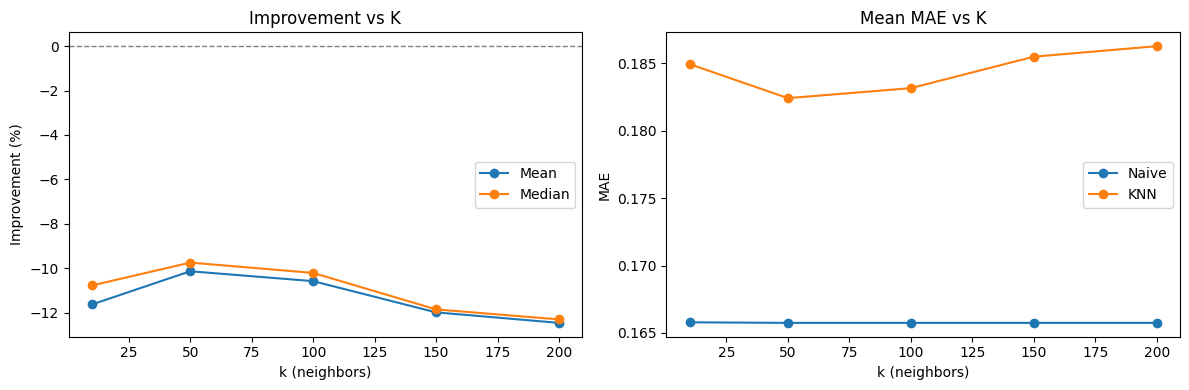

In [22]:
if len(summary_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(summary_df['k'], summary_df['mean_improvement_pct'], marker='o', label='Mean')
    axes[0].plot(summary_df['k'], summary_df['median_improvement_pct'], marker='o', label='Median')
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[0].set_title('Improvement vs K')
    axes[0].set_xlabel('k (neighbors)')
    axes[0].set_ylabel('Improvement (%)')
    axes[0].legend()

    axes[1].plot(summary_df['k'], summary_df['mean_naive_mae'], marker='o', label='Naive')
    axes[1].plot(summary_df['k'], summary_df['mean_knn_mae'], marker='o', label='KNN')
    axes[1].set_title('Mean MAE vs K')
    axes[1].set_xlabel('k (neighbors)')
    axes[1].set_ylabel('MAE')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 8. Sweep Context/Horizon Lengths

In [23]:
context_lengths = [1, 3, 6, 12]
horizon_lengths = [3, 6, 9, 12]

sweep_rows = []

for c_len in context_lengths:
    for h_len in horizon_lengths:
        df = compute_cv_for_k(k_default, context_len=c_len, horizon_len=h_len)
        if df.empty:
            sweep_rows.append({
                'context_len': c_len,
                'horizon_len': h_len,
                'mean_naive_mae': np.nan,
                'mean_knn_mae': np.nan,
                'mean_naive_mape_pct': np.nan,
                'mean_knn_mape_pct': np.nan,
                'mean_naive_bias': np.nan,
                'mean_knn_bias': np.nan,
                'mean_improvement_pct': np.nan,
                'n_periods': 0
            })
            continue

        sweep_rows.append({
            'context_len': c_len,
            'horizon_len': h_len,
            'mean_naive_mae': df['naive_mae'].mean(),
            'mean_knn_mae': df['knn_mae'].mean(),
            'mean_naive_mape_pct': df['naive_mape_pct'].mean(),
            'mean_knn_mape_pct': df['knn_mape_pct'].mean(),
            'mean_naive_bias': df['naive_bias'].mean(),
            'mean_knn_bias': df['knn_bias'].mean(),
            'mean_improvement_pct': df['improvement_pct'].mean(),
            'n_periods': df['end_period'].nunique()
        })

sweep_df = pd.DataFrame(sweep_rows)
print("\nContext/Horizon summary")
print(sweep_df)


Context/Horizon summary
    context_len  horizon_len  mean_naive_mae  mean_knn_mae  \
0             1            3        0.165748      0.182423   
1             1            6        0.158184      0.177503   
2             1            9        0.153394      0.175278   
3             1           12        0.150820      0.173361   
4             3            3        0.166116      0.178510   
5             3            6        0.158474      0.173885   
6             3            9        0.153368      0.171205   
7             3           12        0.150485      0.169201   
8             6            3        0.166838      0.175426   
9             6            6        0.158946      0.170016   
10            6            9        0.153819      0.167266   
11            6           12        0.151404      0.165654   
12           12            3        0.165706      0.171912   
13           12            6        0.157934      0.167203   
14           12            9        0.153030 

## 9. Heatmap of Mean Improvement

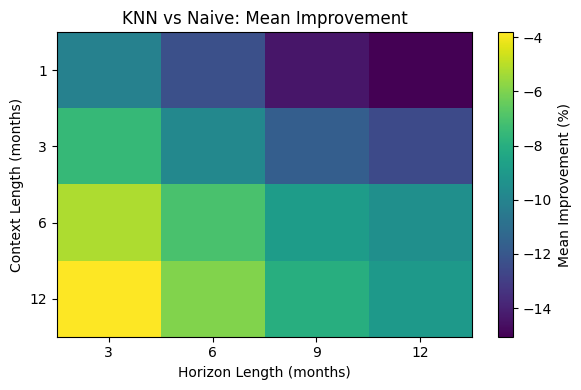

In [24]:
pivot = sweep_df.pivot(index='context_len', columns='horizon_len', values='mean_improvement_pct')

plt.figure(figsize=(6, 4))
plt.imshow(pivot.values, aspect='auto')
plt.colorbar(label='Mean Improvement (%)')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('Horizon Length (months)')
plt.ylabel('Context Length (months)')
plt.title('KNN vs Naive: Mean Improvement')
plt.tight_layout()
plt.show()

# 10. Plot Heatmap of MAE and MAPE

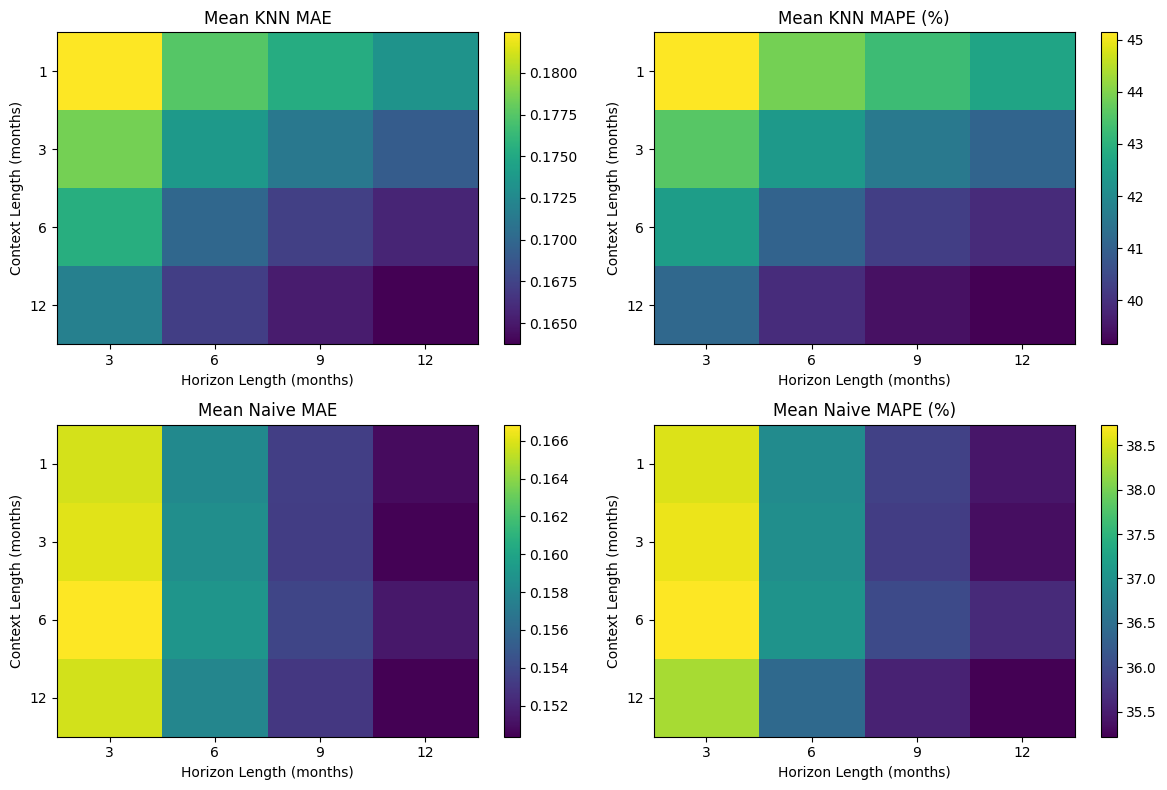

In [25]:
knn_mae_pivot = sweep_df.pivot(index='context_len', columns='horizon_len', values='mean_knn_mae')
knn_mape_pivot = sweep_df.pivot(index='context_len', columns='horizon_len', values='mean_knn_mape_pct')
naive_mae_pivot = sweep_df.pivot(index='context_len', columns='horizon_len', values='mean_naive_mae')
naive_mape_pivot = sweep_df.pivot(index='context_len', columns='horizon_len', values='mean_naive_mape_pct')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

im0 = axes[0, 0].imshow(knn_mae_pivot.values, aspect='auto')
axes[0, 0].set_title('Mean KNN MAE')
axes[0, 0].set_xticks(range(len(knn_mae_pivot.columns)), knn_mae_pivot.columns)
axes[0, 0].set_yticks(range(len(knn_mae_pivot.index)), knn_mae_pivot.index)
axes[0, 0].set_xlabel('Horizon Length (months)')
axes[0, 0].set_ylabel('Context Length (months)')
fig.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(knn_mape_pivot.values, aspect='auto')
axes[0, 1].set_title('Mean KNN MAPE (%)')
axes[0, 1].set_xticks(range(len(knn_mape_pivot.columns)), knn_mape_pivot.columns)
axes[0, 1].set_yticks(range(len(knn_mape_pivot.index)), knn_mape_pivot.index)
axes[0, 1].set_xlabel('Horizon Length (months)')
axes[0, 1].set_ylabel('Context Length (months)')
fig.colorbar(im1, ax=axes[0, 1])

im2 = axes[1, 0].imshow(naive_mae_pivot.values, aspect='auto')
axes[1, 0].set_title('Mean Naive MAE')
axes[1, 0].set_xticks(range(len(naive_mae_pivot.columns)), naive_mae_pivot.columns)
axes[1, 0].set_yticks(range(len(naive_mae_pivot.index)), naive_mae_pivot.index)
axes[1, 0].set_xlabel('Horizon Length (months)')
axes[1, 0].set_ylabel('Context Length (months)')
fig.colorbar(im2, ax=axes[1, 0])

im3 = axes[1, 1].imshow(naive_mape_pivot.values, aspect='auto')
axes[1, 1].set_title('Mean Naive MAPE (%)')
axes[1, 1].set_xticks(range(len(naive_mape_pivot.columns)), naive_mape_pivot.columns)
axes[1, 1].set_yticks(range(len(naive_mape_pivot.index)), naive_mape_pivot.index)
axes[1, 1].set_xlabel('Horizon Length (months)')
axes[1, 1].set_ylabel('Context Length (months)')
fig.colorbar(im3, ax=axes[1, 1])

plt.tight_layout()
plt.show()